<a href="https://colab.research.google.com/github/smemmishofer/ML4NLP1-2026-Tutorial-Notebooks/blob/main/tutorials_notebooks_in_class_2026/W02_Intro_to_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Basics with `sklearn`

This notebook mirrors the Machine Learning Basics lecture. We begin with the Time flies example, then build a sentiment-classification pipeline while examining text representation, data leakage, the sklearn estimator API, prediction, and evaluation.


## 1. Feature Representation (The "Time Flies" example)

Before diving into a real dataset, let's understand how text is transformed into numbers. Machine learning models cannot read raw strings; they require numerical feature vectors.

`CountVectorizer` creates a vocabulary and represents each document by the number of times each vocabulary item occurs. In this tiny corpus, all counts happen to be 0 or 1.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

tiny_corpus = [
    'Time flies like an arrow.',
    'Fruit flies like a banana.'
]

vec = CountVectorizer()
# Test Comment/ Change
X = vec.fit_transform(tiny_corpus)

print('Features:')
print(vec.get_feature_names_out())

print('\nDocument-term count matrix:')
print(X.toarray())

print('\nLearned Vocabulary (Word -> Column Index):')
print(vec.vocabulary_)

# --- The Out-Of-Vocabulary (OOV) Problem ---
new_sentence = ['A fruit fly likes an apple.']
X_new = vec.transform(new_sentence)

print('\n--- Out-Of-Vocabulary Example ---')
print(f'New sentence: "{new_sentence[0]}"')
print('Vectorized representation:', X_new.toarray())
print('\nWords such as "fly", "likes", and "apple" are not in the fitted vocabulary, ')
print('so they have no feature coordinate and do not affect the resulting vector.')
print('This illustrates one kind of information loss in a fixed-vocabulary bag-of-words representation.')

Features:
['an' 'arrow' 'banana' 'flies' 'fruit' 'like' 'time']

Document-term count matrix:
[[1 1 0 1 0 1 1]
 [0 0 1 1 1 1 0]]

Learned Vocabulary (Word -> Column Index):
{'time': 6, 'flies': 3, 'like': 5, 'an': 0, 'arrow': 1, 'fruit': 4, 'banana': 2}

--- Out-Of-Vocabulary Example ---
New sentence: "A fruit fly likes an apple."
Vectorized representation: [[1 0 0 0 1 0 0]]

Words such as "fly", "likes", and "apple" are not in the fitted vocabulary, 
so they have no feature coordinate and do not affect the resulting vector.
This illustrates one kind of information loss in a fixed-vocabulary bag-of-words representation.


## 2. Real Data: Sentiment Classification

We will use the classic NLTK Movie Reviews dataset to perform sentiment analysis (positive vs. negative). Our first step is to split the data so that the test set remains held out during model development.

For simplicity, this notebook initially uses only train and test data because we are not yet comparing configurations. Once we start choosing features or hyperparameters based on performance, we need development data; the test set must remain outside that loop.


In [ ]:
import nltk
from nltk.corpus import movie_reviews
import random
from sklearn.model_selection import train_test_split

# Download the dataset (only needed once)
nltk.download('movie_reviews', quiet=True)

# Load documents and labels
documents = [(' '.join(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

X_all = [text for (text, label) in documents]
y_all = [label for (text, label) in documents]

# Perform the data split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all,
)

print(f'Training examples: {len(X_train)}')
print(f'Test examples: {len(X_test)}')
print(f'Classes: {movie_reviews.categories()}')

/Users/siclemat/lehre/hs26/ml4nlp1/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.14/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/Users/siclemat/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


Training examples: 1600
Test examples: 400
Classes: ['neg', 'pos']


## 3. The Data Leakage Trap (Doing it wrong)

What happens if we fit our vectorizer on **all** the text before splitting? This is a classic data leakage mistake.


In [ ]:
vec_wrong = CountVectorizer()

# WRONG: Fitting on the entire dataset (Train + Test)
vec_wrong.fit(X_all)

print(f'Leaked Vocabulary Size: {len(vec_wrong.vocabulary_)}')
print('vec_wrong has learned vocabulary information from the test set. The test data is therefore no longer fully held out.')
print('General rule: any data-dependent preprocessing step must be fitted on the training data only.')


Leaked Vocabulary Size: 39659
vec_wrong has learned vocabulary information from the test set. The test data is therefore no longer fully held out.
General rule: any data-dependent preprocessing step must be fitted on the training data only.


Let's see exactly what information crossed the boundary. We will fit a proper vectorizer on the training data, and compare it to the leaked vectorizer:


In [ ]:
vec_train = CountVectorizer()
vec_train.fit(X_train)

test_only_features = (
    set(vec_wrong.get_feature_names_out())
    - set(vec_train.get_feature_names_out())
)
print(f'Features learned only through leakage: {len(test_only_features)}')
print('Examples of leaked words:', sorted(test_only_features)[:20])

Features learned only through leakage: 3307
Examples of leaked words: ['03', '04', '05425', '112', '117', '121', '123', '128', '140', '1521', '157', '170', '1791', '1830s', '18s', '1920s', '1952', '1hr', '2010', '2013']


## 4. The Correct Workflow: Fit on Train, Apply to Held-Out Data

The vectorizer must only learn its state (the vocabulary) from the training data.


In [ ]:
vec = CountVectorizer()

# 1. Learn state from training data
vec.fit(X_train)

# 2. Apply state to create features
X_train_vec = vec.transform(X_train)

# Equivalent shorthand for the first two lines:
# X_train_vec = vec.fit_transform(X_train)

# 3. Apply the SAME state to test data
X_test_vec = vec.transform(X_test)

print(f'Correct Vocabulary Size: {len(vec.vocabulary_)}')
print('Notice how it is smaller than the leaked vocabulary. We are properly blind to the test set.')

Correct Vocabulary Size: 36352
Notice how it is smaller than the leaked vocabulary. We are properly blind to the test set.


## 5. Adding the Predictor

Now we fit a predictor on the feature matrix. `LogisticRegression` learns coefficients and an intercept from the training examples and labels.


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and fit the predictor
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

# Predict on the test set
y_pred = clf.predict(X_test_vec)
print('First 10 predictions:', y_pred[:10])

First 10 predictions: ['neg' 'neg' 'pos' 'neg' 'neg' 'pos' 'pos' 'neg' 'neg' 'pos']


## 6. The Pipeline (Putting it all in a box)

Instead of manually managing the vectorizer and the classifier, `sklearn` lets us combine them into a `Pipeline`. A Pipeline combines the vectorizer and classifier into one estimator. During fit, each training-dependent step is fitted in the correct order; during predict, the fitted transformations are applied before prediction. This makes it much easier to keep data-dependent preprocessing inside the training workflow and avoid leakage.


In [ ]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('features', CountVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

# One call triggers fit() on the vectorizer and fit() on the classifier in sequence
pipe.fit(X_train, y_train)

# One call triggers transform() on the vectorizer and predict() on the classifier
y_pred_pipe = pipe.predict(X_test)

print('Prediction: should the two approaches produce the same labels?')
print('Predictions match manual steps?', (y_pred == y_pred_pipe).all())

Prediction: should the two approaches produce the same labels?
Predictions match manual steps? True


## 7. Know Your Data: Inspecting Predictions and Probabilities

Aggregate metrics such as accuracy summarize performance, but they do not explain individual successes and failures. Inspecting predictions helps us understand what kinds of examples the model handles well or poorly. `predict_proba` returns the model's estimated probability for each class.


In [ ]:
import textwrap

probs = pipe.predict_proba(X_test)
classes = pipe.classes_

# Find some correct and incorrect predictions
correct_idx = [i for i, (gold, pred) in enumerate(zip(y_test, y_pred_pipe)) if gold == pred]
errors_idx = [i for i, (gold, pred) in enumerate(zip(y_test, y_pred_pipe)) if gold != pred]

# Select 2 correct and 2 incorrect
inspect_indices = correct_idx[:2] + errors_idx[:2]

for i in inspect_indices:
    text = X_test[i]
    true_label = y_test[i]
    pred_label = y_pred_pipe[i]

    prob_str = ' | '.join([f'{cls}: {p:.1%}' for cls, p in zip(classes, probs[i])])

    status = '✅ Correct' if true_label == pred_label else '❌ Incorrect'
    print(f'--- Example {i} ({status}) ---')
    print(f'True Label: {true_label}  |  Predicted Label: {pred_label}')
    print(f'Probabilities:  [{prob_str}]')
    print('Text:', textwrap.shorten(text, width=200, placeholder=" [...]"))
    print()

print('Question: What might make the incorrect examples difficult under a bag-of-words representation?')

--- Example 0 (✅ Correct) ---
True Label: neg  |  Predicted Label: neg
Probabilities:  [neg: 98.8% | pos: 1.2%]
Text: dr dolittle ( 20th century fox ) running time : 1 hour 25 minutes starring eddie murphy directed by betty thomas riding high on the success of the nutty professor ( 1996 ) , murphy returns in [...]

--- Example 1 (✅ Correct) ---
True Label: neg  |  Predicted Label: neg
Probabilities:  [neg: 99.9% | pos: 0.1%]
Text: " spawn " features good guys , bad guys , lots of fighting , bloody violence , a leather - clad machine gun chick , gooey , self - healing bullet holes , scatological humor and a man - eating [...]

--- Example 10 (❌ Incorrect) ---
True Label: neg  |  Predicted Label: pos
Probabilities:  [neg: 6.0% | pos: 94.0%]
Text: in the line of duty is the critically praised series of television movies dealing with the real - life incidents that claimed lives of law enforcement officers in usa . the twilight murders , [...]

--- Example 14 (❌ Incorrect) ---
True Label: n

## 8. Evaluation & Evidence

Finally, we evaluate our pipeline. A single accuracy score compresses behavior, but a Confusion Matrix shows us exactly which distinctions fail (e.g., are we misclassifying positive reviews as negative, or vice-versa?). Percentages are normalized within each gold-label row, answering: _Of the examples whose gold label is this class, where did they go?_


Accuracy: 0.860


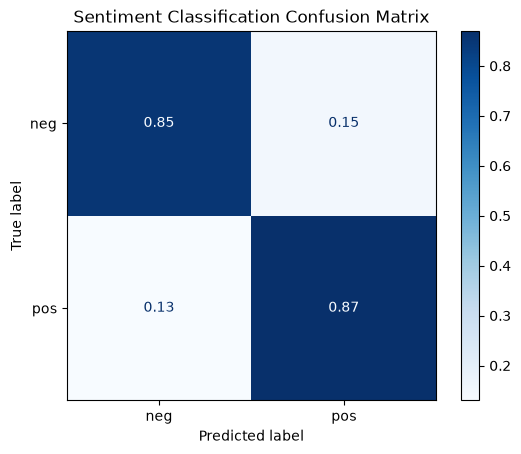

In [ ]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_pred_pipe)
print(f'Accuracy: {acc:.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_pipe,
    labels=pipe.classes_,
    normalize='true',
    cmap='Blues'
)
plt.title('Sentiment Classification Confusion Matrix')
plt.show()

## What have we learned?

We now have a complete text-classification workflow:

`raw text` → `fitted representation` → `feature matrix` → `fitted predictor` → `predictions` → `evaluation`

- `CountVectorizer.fit` learned the vocabulary.
- `LogisticRegression.fit` learned classifier parameters.
- Both learned only from training data.
- The `Pipeline` packages these dependencies into one estimator.

One box remains unopened: how does the linear classifier combine the features to make a prediction? That is the topic of Linear Classification for NLP.


## What to explore next?

Here are some questions you can investigate by modifying the examples in this notebook:

- What changes in the document vector when a word occurs more than once? What changes when `binary=True` is passed to `CountVectorizer`?
- Which words occur only in the development or test data? What happens to them when the training vocabulary is applied?
- Which development examples does the model classify incorrectly with high probability? What information might a bag-of-words representation be missing?
- How does limiting the vocabulary with `max_features` affect development accuracy and the kinds of errors the model makes?
- If you compare two pipeline configurations, which data should guide your choice? When should you look at the test result?
- What might the learned coefficients reveal about how the linear classifier combines word features?

When experimenting, keep the test set outside the development loop: make choices using training and development data, then use the test set once for the final estimate.
